In [49]:
import os
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from PIL import Image
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score,
                             recall_score, balanced_accuracy_score, f1_score)

RANDOM_STATE = 42
IMG_SIZE = 224
np.random.seed(RANDOM_STATE)

## Kaggle dataset setup

Download `kmader/skin-cancer-mnist-ham10000` with `kagglehub`, reads `HAM10000_metadata.csv`, and maps each `image_id` to the corresponding JPG in the two image folders.

In [50]:
# Download the dataset from Kaggle

DATASET = "kmader/skin-cancer-mnist-ham10000"
data_dir = Path(kagglehub.dataset_download(DATASET))

print("Dataset directory:", data_dir)
print("Top-level files/folders:")
for path in sorted(data_dir.iterdir()):
    print(" -", path.name)
    
images_part_1_dir = data_dir / "HAM10000_images_part_1"
images_part_2_dir = data_dir / "HAM10000_images_part_2"

print("Number of images in 'HAM10000_images_part_1':", len(list(images_part_1_dir.glob("*.jpg"))))
print("Number of images in 'HAM10000_images_part_2':", len(list(images_part_2_dir.glob("*.jpg"))))

Dataset directory: C:\Users\thanh\.cache\kagglehub\datasets\kmader\skin-cancer-mnist-ham10000\versions\2
Top-level files/folders:
 - HAM10000_images_part_1
 - HAM10000_images_part_2
 - HAM10000_metadata.csv
 - hmnist_28_28_L.csv
 - hmnist_28_28_RGB.csv
 - hmnist_8_8_L.csv
 - hmnist_8_8_RGB.csv
Number of images in 'HAM10000_images_part_1': 5000
Number of images in 'HAM10000_images_part_2': 5015


In [51]:
# Load metadata and map every image_id to its JPG file

metadata = list(data_dir.rglob("HAM10000_metadata.csv"))
if not metadata:
    raise FileNotFoundError("HAM10000_metadata.csv was not found.")

metadata_path = metadata[0]
df = pd.read_csv(metadata_path)

# Images are stored across HAM10000_images_part_1 and part_2
image_files = list(data_dir.rglob("*.jpg"))
image_path_by_id = {path.stem: str(path) for path in image_files}
df["image_path"] = df["image_id"].map(image_path_by_id)

missing_images = df["image_path"].isna().sum()
if missing_images:
    missing_ids = df.loc[df["image_path"].isna(), "image_id"].head(10).tolist()
    raise FileNotFoundError(
        f"Could not locate {missing_images} image files. Example missing IDs: {missing_ids}"
    )

print(df.head())
print("Metadata shape:", df.shape)
print("Images discovered:", len(image_path_by_id))


     lesion_id      image_id   dx dx_type   age   sex localization  \
0  HAM_0000118  ISIC_0027419  bkl   histo  80.0  male        scalp   
1  HAM_0000118  ISIC_0025030  bkl   histo  80.0  male        scalp   
2  HAM_0002730  ISIC_0026769  bkl   histo  80.0  male        scalp   
3  HAM_0002730  ISIC_0025661  bkl   histo  80.0  male        scalp   
4  HAM_0001466  ISIC_0031633  bkl   histo  75.0  male          ear   

                                          image_path  
0  C:\Users\thanh\.cache\kagglehub\datasets\kmade...  
1  C:\Users\thanh\.cache\kagglehub\datasets\kmade...  
2  C:\Users\thanh\.cache\kagglehub\datasets\kmade...  
3  C:\Users\thanh\.cache\kagglehub\datasets\kmade...  
4  C:\Users\thanh\.cache\kagglehub\datasets\kmade...  
Metadata shape: (10015, 8)
Images discovered: 10015


## Prepare labels to split Train/Test sets

In [52]:
label_encoder = LabelEncoder()
df["label"] = label_encoder.fit_transform(df["dx"])
class_names = label_encoder.classes_

print("Classes:", list(enumerate(class_names)))
print("Full dataset shape:", df.shape)
print("Unique lesions:", df["lesion_id"].nunique())

Classes: [(0, 'akiec'), (1, 'bcc'), (2, 'bkl'), (3, 'df'), (4, 'mel'), (5, 'nv'), (6, 'vasc')]
Full dataset shape: (10015, 9)
Unique lesions: 7470


In [53]:
sgkf = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)\
    
df["fold"] = -1
for fold, (_, fold_indices) in enumerate(
    sgkf.split(df, y=df["label"], groups=df["lesion_id"])
):
    df.loc[fold_indices, "fold"] = fold
    
df["fold"] = -1
for fold, (_, fold_indices) in enumerate(sgkf.split(df, y=df["label"], groups=df["lesion_id"])):
    df.loc[fold_indices, "fold"] = fold

test_fold = 0           # Choose first fold as test set
validation_fold = 1     # Choose second fold as validation set

train_df = df.loc[~ df["fold"].isin([test_fold, validation_fold])].copy()   # Copy Folds 2-9 for training
val_df = df.loc[df["fold"] == validation_fold].copy()
test_df = df.loc[df["fold"] == test_fold].copy()

for split_name, split_df in {
    "train": train_df,
    "validation": val_df,
    "test": test_df,
}.items():
    print(
        f"{split_name:10s}: {len(split_df):5d} images, "
        f"{split_df['lesion_id'].nunique():5d} lesions"
    )
    print(split_df["dx"].value_counts(normalize=True).sort_index().round(3))
    print()

# Leakage checks.
train_lesions = set(train_df["lesion_id"])
val_lesions = set(val_df["lesion_id"])
test_lesions = set(test_df["lesion_id"])

assert train_lesions.isdisjoint(val_lesions)
assert train_lesions.isdisjoint(test_lesions)
assert val_lesions.isdisjoint(test_lesions)
assert len(train_df) + len(val_df) + len(test_df) == len(df)

print("No Leakage (no lesion_id appears in multiple splits).")

train     :  8011 images,  5975 lesions
dx
akiec    0.033
bcc      0.051
bkl      0.110
df       0.011
mel      0.111
nv       0.669
vasc     0.014
Name: proportion, dtype: float64

validation:  1002 images,   748 lesions
dx
akiec    0.033
bcc      0.052
bkl      0.110
df       0.011
mel      0.111
nv       0.670
vasc     0.014
Name: proportion, dtype: float64

test      :  1002 images,   747 lesions
dx
akiec    0.032
bcc      0.051
bkl      0.110
df       0.012
mel      0.112
nv       0.670
vasc     0.014
Name: proportion, dtype: float64

No Leakage (no lesion_id appears in multiple splits).


In [54]:
# Dataframe process for CNN model
IMAGE_SIZE = (32, 32)

def load_image_array(image_path, size=IMAGE_SIZE):
    """Load one local JPG as a normalized RGB NumPy array."""
    with Image.open(image_path) as image:
        image = image.convert("RGB").resize(size)
        return np.asarray(image, dtype=np.float32) / 255.0


def dataframe_to_arrays(split_df):
    """Convert one metadata split into image and integer-label arrays."""
    X = np.stack([load_image_array(path) for path in split_df["image_path"]])
    y = split_df["label"].to_numpy(dtype=np.int64)
    return X, y

X_train, y_train = dataframe_to_arrays(train_df)
X_val, y_val = dataframe_to_arrays(val_df)
X_test, y_test = dataframe_to_arrays(test_df)

print("Training set:  ", X_train.shape, y_train.shape)
print("Validation set:", X_val.shape, y_val.shape)
print("Test set:      ", X_test.shape, y_test.shape)
print("Pixel range:", float(X_train.min()), "to", float(X_train.max()))

Training set:   (8011, 32, 32, 3) (8011,)
Validation set: (1002, 32, 32, 3) (1002,)
Test set:       (1002, 32, 32, 3) (1002,)
Pixel range: 0.0 to 1.0


## EDA & Preprocessing

In [56]:
print(train_df.head())
train_df.shape

     lesion_id      image_id   dx dx_type   age   sex localization  \
0  HAM_0000118  ISIC_0027419  bkl   histo  80.0  male        scalp   
1  HAM_0000118  ISIC_0025030  bkl   histo  80.0  male        scalp   
4  HAM_0001466  ISIC_0031633  bkl   histo  75.0  male          ear   
5  HAM_0001466  ISIC_0027850  bkl   histo  75.0  male          ear   
6  HAM_0002761  ISIC_0029176  bkl   histo  60.0  male         face   

                                          image_path  label  fold  
0  C:\Users\thanh\.cache\kagglehub\datasets\kmade...      2     8  
1  C:\Users\thanh\.cache\kagglehub\datasets\kmade...      2     8  
4  C:\Users\thanh\.cache\kagglehub\datasets\kmade...      2     5  
5  C:\Users\thanh\.cache\kagglehub\datasets\kmade...      2     5  
6  C:\Users\thanh\.cache\kagglehub\datasets\kmade...      2     2  


(8011, 10)

In [57]:
train_df.info()
train_df.describe().T
train_df.columns.tolist()

<class 'pandas.core.frame.DataFrame'>
Index: 8011 entries, 0 to 10014
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     8011 non-null   object 
 1   image_id      8011 non-null   object 
 2   dx            8011 non-null   object 
 3   dx_type       8011 non-null   object 
 4   age           7961 non-null   float64
 5   sex           8011 non-null   object 
 6   localization  8011 non-null   object 
 7   image_path    8011 non-null   object 
 8   label         8011 non-null   int64  
 9   fold          8011 non-null   int64  
dtypes: float64(1), int64(2), object(7)
memory usage: 688.4+ KB


['lesion_id',
 'image_id',
 'dx',
 'dx_type',
 'age',
 'sex',
 'localization',
 'image_path',
 'label',
 'fold']

In [58]:
print("\nMissing values per column:")
display(train_df.isnull().sum())

print('\nDuplicate values per column:')
display(train_df.drop(columns=['image_path']).duplicated().sum())


Missing values per column:


lesion_id        0
image_id         0
dx               0
dx_type          0
age             50
sex              0
localization     0
image_path       0
label            0
fold             0
dtype: int64


Duplicate values per column:


np.int64(0)

In [59]:
print('\nFill missing values in \'age\' with the most common age:')
train_df['age'] = train_df['age'].fillna(train_df['age'].median())
display(train_df.isnull().sum())


Fill missing values in 'age' with the most common age:


lesion_id       0
image_id        0
dx              0
dx_type         0
age             0
sex             0
localization    0
image_path      0
label           0
fold            0
dtype: int64

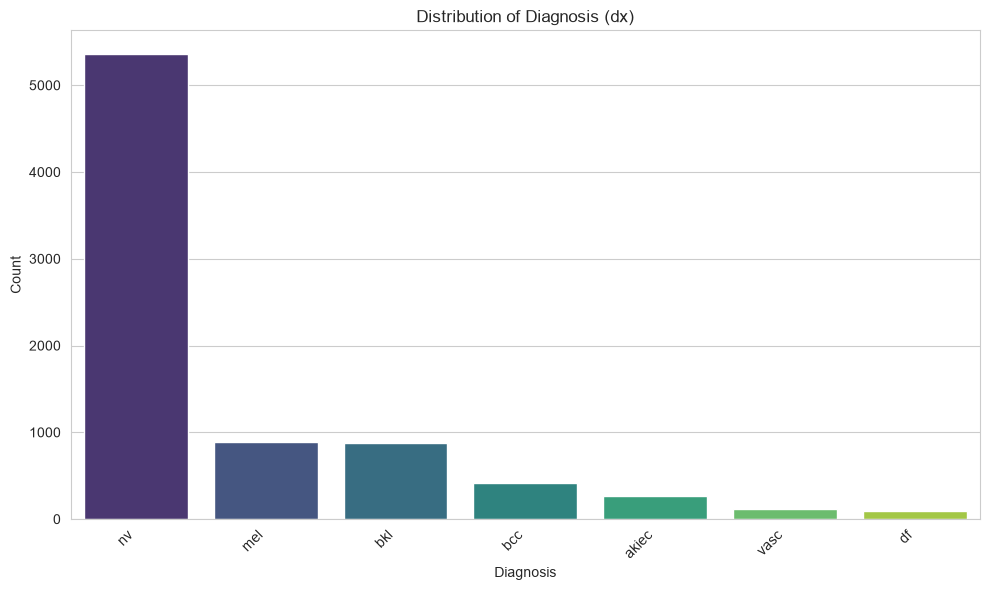

In [60]:
sns.set_style("whitegrid")

# 1. Distribution of 'dx' (diagnosis)
plt.figure(figsize=(10, 6))
sns.countplot(data=train_df, x='dx', order=train_df['dx'].value_counts().index, palette='viridis')
plt.title('Distribution of Diagnosis (dx)')
plt.xlabel('Diagnosis')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

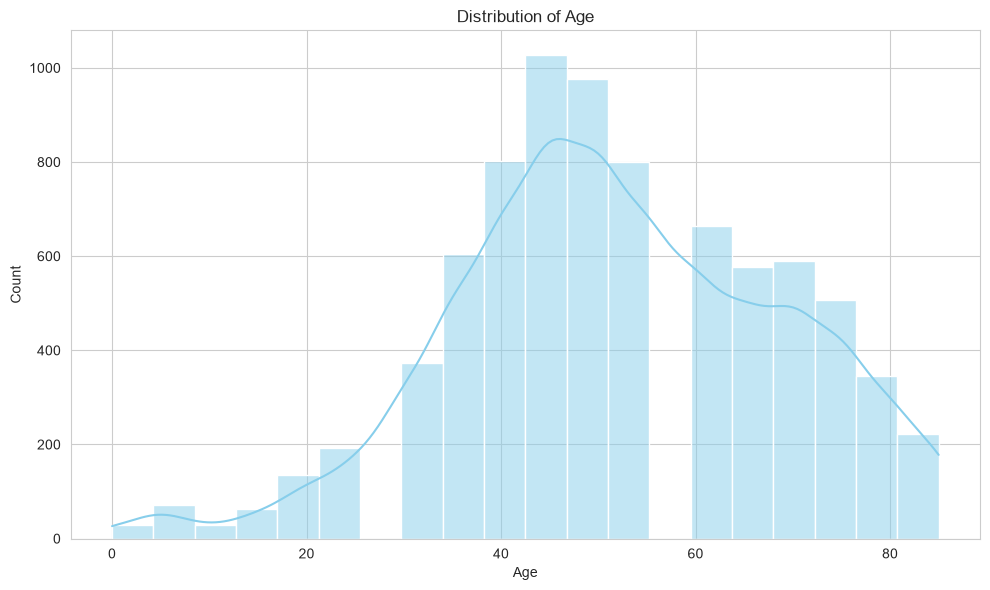

In [61]:
# 2. Distribution of 'age'
plt.figure(figsize=(10, 6))
sns.histplot(data=train_df, x='age', kde=True, bins=20, color='skyblue')
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

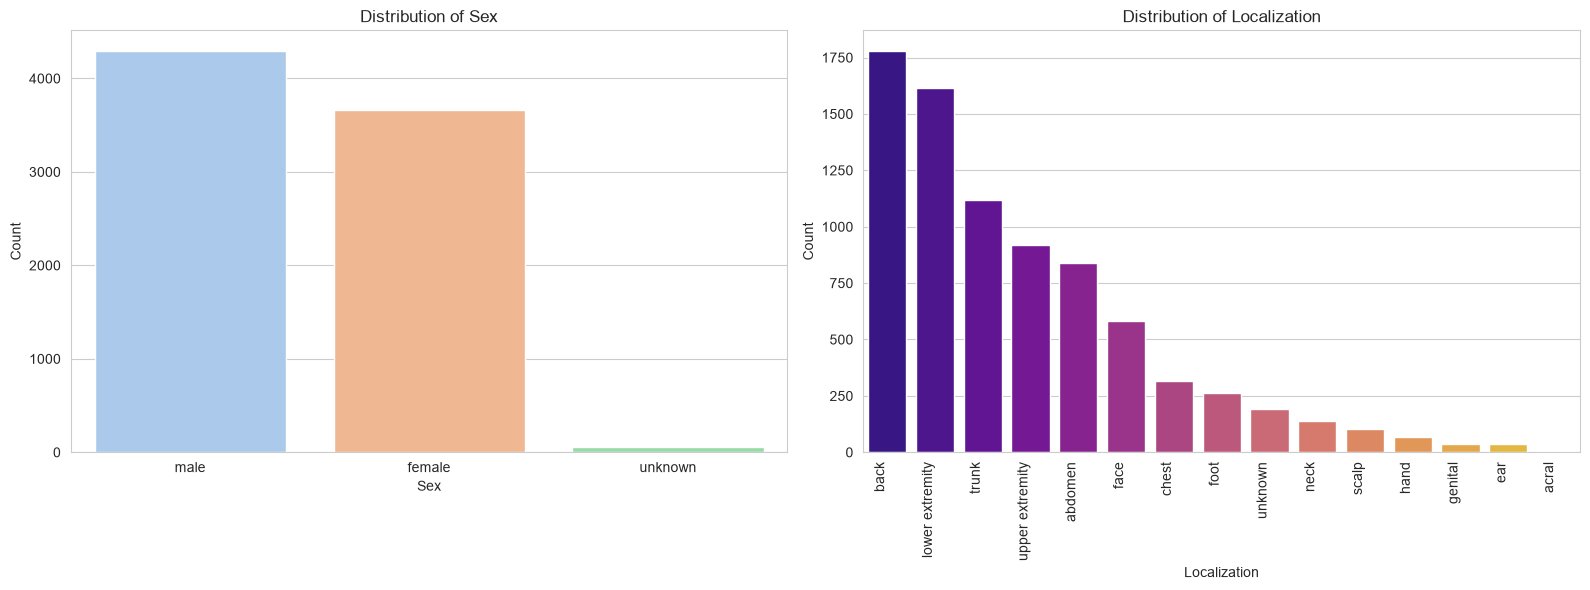

In [62]:
# 3. Distributions of 'sex' and 'localization'
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.countplot(data=train_df, x='sex', ax=axes[0], palette='pastel', order=train_df['sex'].value_counts().index)
axes[0].set_title('Distribution of Sex')
axes[0].set_xlabel('Sex')
axes[0].set_ylabel('Count')

sns.countplot(data=train_df, x='localization', ax=axes[1], palette='plasma', order=train_df['localization'].value_counts().index)
axes[1].set_title('Distribution of Localization')
axes[1].set_xlabel('Localization')
axes[1].set_ylabel('Count')
plt.setp(axes[1].get_xticklabels(), rotation=90, horizontalalignment='right')

plt.tight_layout()
plt.show()

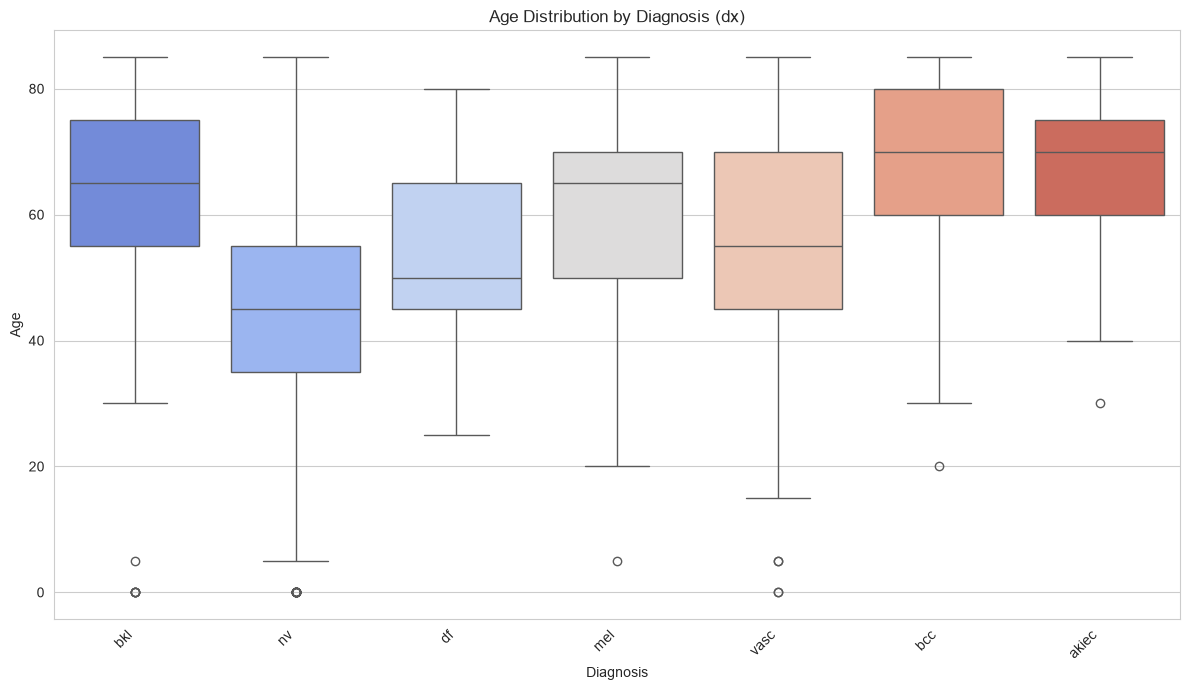

In [63]:
# 4. Age distribution by 'dx'
plt.figure(figsize=(12, 7))
sns.boxplot(data=train_df, x='dx', y='age', palette='coolwarm')
plt.title('Age Distribution by Diagnosis (dx)')
plt.xlabel('Diagnosis')
plt.ylabel('Age')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [64]:
train_df_encoded = pd.get_dummies(train_df, columns=['dx'], prefix='dx')

# Display the first few rows of the DataFrame with the new encoded columns
display(train_df_encoded.head())

# Display the names of the new columns created by one-hot encoding
print(f"\nNew columns created: {train_df_encoded.columns[train_df_encoded.columns.str.startswith('dx_')].tolist()}")

,lesion_id,image_id,dx_type,age,sex,localization,image_path,label,fold,dx_akiec,dx_bcc,dx_bkl,dx_df,dx_mel,dx_nv,dx_vasc
0,HAM_0000118,ISIC_0027419,histo,80.0,male,scalp,C:\Users\thanh\.cache\kagglehub\datasets\kmade...,2,8,False,False,True,False,False,False,False
1,HAM_0000118,ISIC_0025030,histo,80.0,male,scalp,C:\Users\thanh\.cache\kagglehub\datasets\kmade...,2,8,False,False,True,False,False,False,False
4,HAM_0001466,ISIC_0031633,histo,75.0,male,ear,C:\Users\thanh\.cache\kagglehub\datasets\kmade...,2,5,False,False,True,False,False,False,False
5,HAM_0001466,ISIC_0027850,histo,75.0,male,ear,C:\Users\thanh\.cache\kagglehub\datasets\kmade...,2,5,False,False,True,False,False,False,False
6,HAM_0002761,ISIC_0029176,histo,60.0,male,face,C:\Users\thanh\.cache\kagglehub\datasets\kmade...,2,2,False,False,True,False,False,False,False



New columns created: ['dx_type', 'dx_akiec', 'dx_bcc', 'dx_bkl', 'dx_df', 'dx_mel', 'dx_nv', 'dx_vasc']


In [65]:
# Handle Class Imbalance

classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = {
    int(class_id): float(weight)
    for class_id, weight in zip(classes, weights)
}
print(class_weights)

{0: 4.3680479825518, 1: 2.78449774070212, 2: 1.3019665203965545, 3: 12.43944099378882, 4: 1.2858747993579454, 5: 0.21339335659678751, 6: 10.038847117794486}


## Majority Class Baseline

In [ ]:
# Dataframe process for Logistic Regression and Random Forest models
X_train_flat = X_train.reshape(len(X_train), -1)
X_val_flat = X_val.reshape(len(X_val), -1)
X_test_flat = X_test.reshape(len(X_test), -1)

print(X_train_flat.shape)
print(X_val_flat.shape)
print(X_test_flat.shape)

(8011, 3072)
(1002, 3072)
(1002, 3072)


## Logistic Regression Model

## Random Forest Model

In [66]:
# Train Random Forest Classifier


X_train_rf = X_train.reshape(X_train.shape[0], -1)
X_test_rf = X_test.reshape(X_test.shape[0], -1)

print("Random Forest training shape:", X_train_rf.shape)
print("Random Forest test shape:", X_test_rf.shape)

rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight=class_weights,
    random_state=42,
    n_jobs=-1,
)
rf_model.fit(X_train_rf, y_train)


Random Forest training shape: (8011, 3072)
Random Forest test shape: (1002, 3072)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.","{0: 4.3680479825518, 1: 2.78449774070212, 2: 1.3019665203965545, 3: 12.43944099378882, ...}"
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of f

Random Forest Accuracy: 0.673277661795407
Random Forest Balanced Accuracy: 0.47029800342567313

Classification Report:
                               precision    recall  f1-score   support

            actinic_keratoses       0.45      0.43      0.44        63
         basal_cell_carcinoma       0.37      0.58      0.45        98
benign_keratosis-like_lesions       0.39      0.48      0.43       210
               dermatofibroma       0.75      0.27      0.40        22
             melanocytic_Nevi       0.88      0.76      0.82      1281
                     melanoma       0.36      0.55      0.44       215
             vascular_lesions       0.60      0.22      0.32        27

                     accuracy                           0.67      1916
                    macro avg       0.54      0.47      0.47      1916
                 weighted avg       0.73      0.67      0.69      1916



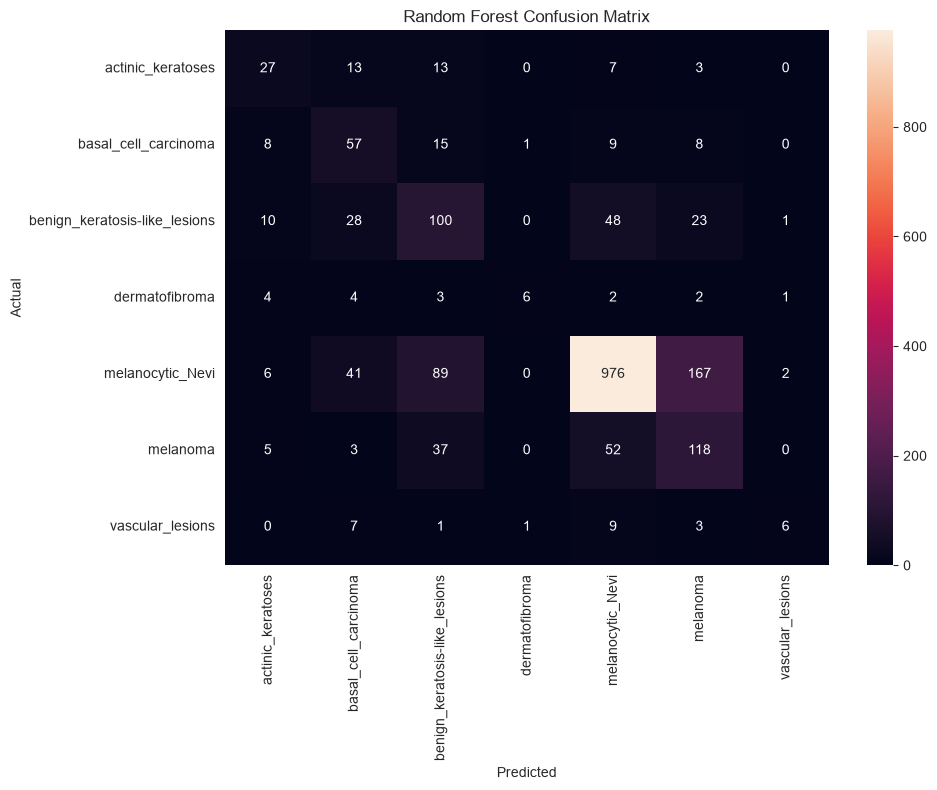

In [17]:
# Evaluate Random Forest Model

rf_predictions = rf_model.predict(X_test_rf)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_predictions))
print("Random Forest Balanced Accuracy:", balanced_accuracy_score(y_test, rf_predictions))
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        rf_predictions,
        labels=np.arange(len(class_names)),
        target_names=class_names,
        zero_division=0,
    )
)

cm = confusion_matrix(y_test, rf_predictions, labels=np.arange(len(class_names)))
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.tight_layout()
plt.show()

## LSTM Model

In [18]:
# Train LSTM Classifier

RUN_LSTM = True

if RUN_LSTM:
    import tensorflow as tf

    tf.random.set_seed(42)

    # Treat image rows as sequence steps; width × channels are features.
    X_train_lstm = X_train.reshape(X_train.shape[0], X_train.shape[1], -1)
    X_test_lstm = X_test.reshape(X_test.shape[0], X_test.shape[1], -1)

    lstm_model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=X_train_lstm.shape[1:]),
        tf.keras.layers.LSTM(64),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dense(len(class_names), activation="softmax"),
    ])

    lstm_model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    lstm_model.fit(
        X_train_lstm,
        y_train,
        validation_split=0.2,
        epochs=10,
        batch_size=64,
        class_weight=class_weights,
        verbose=1,
    )

    test_loss, test_accuracy = lstm_model.evaluate(X_test_lstm, y_test, verbose=0)
    print("LSTM test loss:", test_loss)
    print("LSTM test accuracy:", test_accuracy)
else:
    print("LSTM training skipped. Set RUN_LSTM = True to enable it.")

Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.1142 - loss: 1.9951 - val_accuracy: 0.3594 - val_loss: 1.9544
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.3024 - loss: 1.9564 - val_accuracy: 0.4612 - val_loss: 1.7589
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.3851 - loss: 1.9213 - val_accuracy: 0.4534 - val_loss: 1.6069
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.3863 - loss: 1.8880 - val_accuracy: 0.4638 - val_loss: 1.5991
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.3670 - loss: 1.8890 - val_accuracy: 0.4788 - val_loss: 1.4723
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.4062 - loss: 1.8154 - val_accuracy: 0.4912 - val_loss: 1.5219
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.4525 - loss: 1.7719 - val_accuracy: 0.4566 - val_loss: 1.5687
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.4235 - loss: 1.7548 - val_accuracy: 0.3503 - val_lo

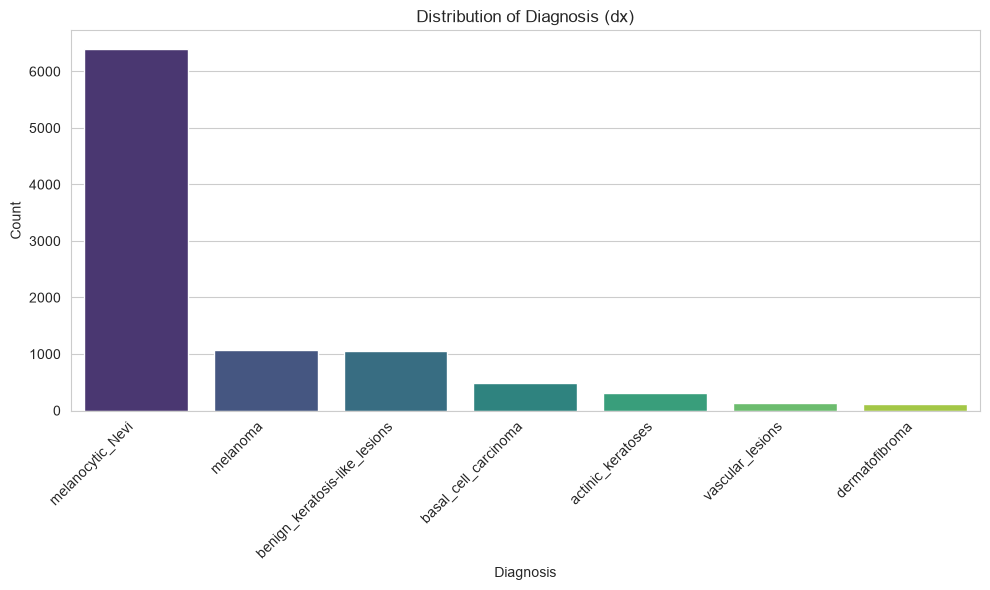

In [19]:
sns.set_style("whitegrid")

# 1. Distribution of 'dx' (diagnosis)
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='dx', order=df['dx'].value_counts().index, palette='viridis')
plt.title('Distribution of Diagnosis (dx)')
plt.xlabel('Diagnosis')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()